# 📈 Stock Price Forecasting — LSTM Model

This notebook trains a **Bidirectional LSTM** to forecast stock closing prices
for a configurable horizon (7 / 14 / 30 days ahead).

### What this notebook does, end to end:
1. Fetches real OHLCV data for any ticker via `yfinance`
2. Engineers 11 technical indicators as model features
3. Splits data temporally (70% train / 15% val / 15% test)
4. Trains a Bidirectional LSTM with early stopping
5. Evaluates on the test set: MAE, RMSE, MAPE, Directional Accuracy
6. Runs a walk-forward backtest with transaction costs
7. Plots training loss, forecast vs actual, and equity curve
8. Saves the model and scaler to Google Drive

**Rules:**
- Scaler fitted on training data only
- Time series is never shuffled
- Test set is touched exactly once

In [11]:
# Block 2 — Install dependencies
# Run this once per Colab session. If the runtime already has these packages
# (e.g. from a previous run in the same session), pip will skip reinstalling them.

!pip install -q yfinance ta torch scikit-learn joblib pandas numpy matplotlib
print("✅ All packages installed.")

✅ All packages installed.


In [12]:
# Block 3 — Imports

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import yfinance as yf
import joblib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Technical indicator library
import ta

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Use GPU if available, otherwise CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Imports complete. Device: {DEVICE}")

✅ Imports complete. Device: cpu


In [13]:
# Block 4 — Mount Google Drive

from google.colab import drive
drive.mount("/content/drive", force_remount=False)
print("✅ Google Drive mounted at /content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted at /content/drive


In [14]:
# Block 5 — Configuration
# ── Edit only this cell ───────────────────────────────────────────────

TICKER        = "AAPL"          # Any yfinance ticker: TSLA, INFY.NS, BTC-USD
START_DATE    = "2018-01-01"
END_DATE      = "2024-12-31"
HORIZON       = 7               # Forecast horizon in days: 7, 14, or 30
WINDOW        = 60              # Lookback window in days (input sequence length)

TRAIN_FRAC    = 0.70
VAL_FRAC      = 0.15
# TEST_FRAC is implicitly 1 - TRAIN_FRAC - VAL_FRAC = 0.15

# ── LSTM hyperparameters ──────────────────────────────────────────────
LSTM_HIDDEN   = 128             # Hidden units per direction (x2 because bidirectional)
LSTM_LAYERS   = 2               # Stacked LSTM layers
LSTM_DROPOUT  = 0.2             # Dropout between LSTM layers
LSTM_LR       = 1e-3            # Adam learning rate
LSTM_EPOCHS   = 100             # Max training epochs
LSTM_PATIENCE = 10              # Early stopping: stop if val loss doesn't improve

# ── Google Drive paths ────────────────────────────────────────────────
DRIVE_DIR     = "/content/drive/MyDrive/stock_forecasting"
DATA_DIR      = os.path.join(DRIVE_DIR, "data")
MODEL_DIR     = os.path.join(DRIVE_DIR, "models")
RESULTS_DIR   = os.path.join(DRIVE_DIR, "results")

# Create directories if they don't exist
for d in [DATA_DIR, MODEL_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"✅ Config set | Ticker: {TICKER} | Horizon: {HORIZON}d | Window: {WINDOW}d")
print(f"   Drive root: {DRIVE_DIR}")

✅ Config set | Ticker: AAPL | Horizon: 7d | Window: 60d
   Drive root: /content/drive/MyDrive/stock_forecasting


In [15]:
# Block 6 — Fetch OHLCV data with yfinance + preview

CACHE_PATH = os.path.join(DATA_DIR, f"{TICKER}_ohlcv.csv")

if os.path.exists(CACHE_PATH):
    print(f"📂 Loading cached data from Drive: {CACHE_PATH}")
    df_raw = pd.read_csv(CACHE_PATH, index_col="Date", parse_dates=True)
else:
    print(f"⬇️  Downloading {TICKER} from {START_DATE} to {END_DATE} ...")
    df_raw = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)
    df_raw.index.name = "Date"
    df_raw.to_csv(CACHE_PATH)
    print(f"💾 Saved to {CACHE_PATH}")

# Keep only OHLCV columns
df_raw = df_raw[["Open", "High", "Low", "Close", "Volume"]].copy()
df_raw.dropna(inplace=True)

print(f"\n✅ Data loaded | Shape: {df_raw.shape}")
print(f"   Date range: {df_raw.index[0].date()} → {df_raw.index[-1].date()}")
print(f"\nFirst 5 rows:")
display(df_raw.head())

⬇️  Downloading AAPL from 2018-01-01 to 2024-12-31 ...


[*********************100%***********************]  1 of 1 completed

💾 Saved to /content/drive/MyDrive/stock_forecasting/data/AAPL_ohlcv.csv

✅ Data loaded | Shape: (1760, 5)
   Date range: 2018-01-02 → 2024-12-30

First 5 rows:


Price,Open,High,Low,Close,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,39.776186,40.276427,39.565802,40.267075,102223600
2018-01-03,40.330187,40.802379,40.196947,40.260059,118071600
2018-01-04,40.332525,40.549921,40.224998,40.447067,89738400
2018-01-05,40.542920,40.994071,40.451755,40.907581,94640000
2018-01-08,40.755638,41.050171,40.657457,40.755638,82271200


In [17]:
df = df_raw.copy()

close = df["Close"].squeeze()
high  = df["High"].squeeze()
low   = df["Low"].squeeze()
vol   = df["Volume"].squeeze()

# ── Trend ─────────────────────────────────────────────────────────────
df["EMA_20"]  = ta.trend.EMAIndicator(close, window=20).ema_indicator()
df["EMA_50"]  = ta.trend.EMAIndicator(close, window=50).ema_indicator()

macd_obj      = ta.trend.MACD(close)
df["MACD"]    = macd_obj.macd()
df["MACD_sig"]= macd_obj.macd_signal()

df["ADX"]     = ta.trend.ADXIndicator(high, low, close, window=14).adx()

# ── Momentum ──────────────────────────────────────────────────────────
df["RSI"]     = ta.momentum.RSIIndicator(close, window=14).rsi()
df["Stoch_K"] = ta.momentum.StochasticOscillator(high, low, close).stoch()

# ── Volatility ────────────────────────────────────────────────────────
bb            = ta.volatility.BollingerBands(close, window=20)
df["BB_high"] = bb.bollinger_hband()
df["BB_low"]  = bb.bollinger_lband()
df["ATR"]     = ta.volatility.AverageTrueRange(high, low, close, window=14).average_true_range()

# ── Volume ────────────────────────────────────────────────────────────
df["OBV"]     = ta.volume.OnBalanceVolumeIndicator(close, vol).on_balance_volume()
df["VWAP"]    = ta.volume.VolumeWeightedAveragePrice(high, low, close, vol).volume_weighted_average_price()

print(f"✅ Feature engineering complete | Columns: {list(df.columns)}")
print(f"   Shape before NaN drop: {df.shape}")

✅ Feature engineering complete | Columns: [('Open', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Close', 'AAPL'), ('Volume', 'AAPL'), ('EMA_20', ''), ('EMA_50', ''), ('MACD', ''), ('MACD_sig', ''), ('ADX', ''), ('RSI', ''), ('Stoch_K', ''), ('BB_high', ''), ('BB_low', ''), ('ATR', ''), ('OBV', ''), ('VWAP', '')]
   Shape before NaN drop: (1760, 17)


In [18]:
# Block 8 — Drop NaNs + confirm feature table

df.dropna(inplace=True)

# Verify
nan_count = df.isna().sum().sum()
assert nan_count == 0, f"❌ Still have {nan_count} NaNs — check indicator windows!"

print(f"✅ NaN drop complete | Shape: {df.shape}")
print(f"   Clean date range: {df.index[0].date()} → {df.index[-1].date()}")
print(f"   NaN count: {nan_count}")
print(f"\nFeature table sample (first 3 rows):")
display(df.head(3))
print(f"\nAll columns ({len(df.columns)}):")
print(list(df.columns))

✅ NaN drop complete | Shape: (1711, 17)
   Clean date range: 2018-03-14 → 2024-12-30
   NaN count: 0

Feature table sample (first 3 rows):


Price,Open,High,Low,Close,Volume,EMA_20,EMA_50,MACD,MACD_sig,ADX,RSI,Stoch_K,BB_high,BB_low,ATR,OBV,VWAP
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,
2018-03-14,42.323013,42.369954,41.733887,41.881756,117473600,41.213041,40.590713,0.642076,0.553161,16.279921,57.985776,54.207936,42.897312,39.626237,0.816093,-312415200,41.687509
2018-03-15,41.895848,42.304246,41.794924,41.931053,90975200,41.281423,40.643275,0.618148,0.566159,16.441393,58.342798,56.108703,42.776820,40.011483,0.794180,-221440000,41.750585
2018-03-16,41.931045,42.041360,41.689294,41.783180,157618800,41.329209,40.687977,0.580559,0.569039,16.424547,56.784053,50.407138,42.795862,40.110499,0.762601,-379058800,41.752057



All columns (17):
[('Open', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Close', 'AAPL'), ('Volume', 'AAPL'), ('EMA_20', ''), ('EMA_50', ''), ('MACD', ''), ('MACD_sig', ''), ('ADX', ''), ('RSI', ''), ('Stoch_K', ''), ('BB_high', ''), ('BB_low', ''), ('ATR', ''), ('OBV', ''), ('VWAP', '')]


In [19]:
# Block 9 — Temporal train/val/test split (70/15/15)
# CRITICAL: Never shuffle time series data.

n = len(df)
train_end = int(n * TRAIN_FRAC)
val_end   = int(n * (TRAIN_FRAC + VAL_FRAC))

df_train = df.iloc[:train_end]
df_val   = df.iloc[train_end:val_end]
df_test  = df.iloc[val_end:]

print("✅ Temporal split complete (no shuffling)")
print(f"\n{'Split':<10} {'Rows':<8} {'Start':<14} {'End'}")
print("-" * 50)
print(f"{'Train':<10} {len(df_train):<8} {str(df_train.index[0].date()):<14} {df_train.index[-1].date()}")
print(f"{'Val':<10} {len(df_val):<8} {str(df_val.index[0].date()):<14} {df_val.index[-1].date()}")
print(f"{'Test':<10} {len(df_test):<8} {str(df_test.index[0].date()):<14} {df_test.index[-1].date()}")
print(f"\nTotal rows: {n} | Fractions — Train: {len(df_train)/n:.1%}, Val: {len(df_val)/n:.1%}, Test: {len(df_test)/n:.1%}")

✅ Temporal split complete (no shuffling)

Split      Rows     Start          End
--------------------------------------------------
Train      1197     2018-03-14     2022-12-12
Val        257      2022-12-13     2023-12-20
Test       257      2023-12-21     2024-12-30

Total rows: 1711 | Fractions — Train: 70.0%, Val: 15.0%, Test: 15.0%


In [21]:
# Block 10 — Fit MinMaxScaler on train only + transform all splits
# CRITICAL: scaler.fit() is called ONLY on df_train.

# The 'Close' column is now a MultiIndex tuple, e.g., ('Close', 'AAPL')
# So, TARGET_COL must reflect this full MultiIndex column name.
TARGET_COL = ('Close', TICKER)

FEATURE_COLS = [c for c in df.columns if c != TARGET_COL]  # All features excluding the correct target MultiIndex
# The original FEATURE_COLS was buggy because c != "Close" would always be true.

# We scale ALL columns (features + target) together so inverse-transform is simple
ALL_COLS = FEATURE_COLS + [TARGET_COL]

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(df_train[ALL_COLS])   # fit + transform
val_scaled   = scaler.transform(df_val[ALL_COLS])          # transform only
test_scaled  = scaler.transform(df_test[ALL_COLS])         # transform only

# Index of the Close (target) column — needed for inverse-scaling later
CLOSE_IDX = ALL_COLS.index(TARGET_COL)

print(f"✅ Scaler fitted on training data only")
print(f"   Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"   Target column: '{TARGET_COL}' at index {CLOSE_IDX}")
print(f"   Scaled shapes — Train: {train_scaled.shape}, Val: {val_scaled.shape}, Test: {test_scaled.shape}")

✅ Scaler fitted on training data only
   Feature columns (16): [('Open', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Volume', 'AAPL'), ('EMA_20', ''), ('EMA_50', ''), ('MACD', ''), ('MACD_sig', ''), ('ADX', ''), ('RSI', ''), ('Stoch_K', ''), ('BB_high', ''), ('BB_low', ''), ('ATR', ''), ('OBV', ''), ('VWAP', '')]
   Target column: '('Close', 'AAPL')' at index 16
   Scaled shapes — Train: (1197, 17), Val: (257, 17), Test: (257, 17)


In [22]:
# Block 11 — Sliding window PyTorch Dataset class

class TimeSeriesDataset(Dataset):
    """
    Converts a scaled 2D numpy array into (X, y) pairs.

    X[i] : scaled[i : i+WINDOW, :]             → shape (WINDOW, n_features)
    y[i] : scaled[i+WINDOW : i+WINDOW+HORIZON, CLOSE_IDX]  → shape (HORIZON,)

    The LSTM receives X as-is: (batch, seq_len, n_features).
    """

    def __init__(self, data: np.ndarray, window: int, horizon: int, close_idx: int):
        self.data      = data
        self.window    = window
        self.horizon   = horizon
        self.close_idx = close_idx

        # Number of valid samples
        self.n_samples = len(data) - window - horizon + 1

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.window, :]                          # (W, F)
        y = self.data[idx + self.window : idx + self.window + self.horizon,
                      self.close_idx]                                       # (H,)
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32)
        )


# Instantiate datasets
train_ds = TimeSeriesDataset(train_scaled, WINDOW, HORIZON, CLOSE_IDX)
val_ds   = TimeSeriesDataset(val_scaled,   WINDOW, HORIZON, CLOSE_IDX)
test_ds  = TimeSeriesDataset(test_scaled,  WINDOW, HORIZON, CLOSE_IDX)

print(f"✅ Dataset created")
print(f"   Train samples: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

✅ Dataset created
   Train samples: 1131 | Val: 191 | Test: 191


In [23]:
# Block 12 — DataLoader setup + shape sanity check

BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# Sanity check — pull one batch
x_batch, y_batch = next(iter(train_loader))
print(f"✅ DataLoaders ready")
print(f"   X batch shape: {x_batch.shape}   ← (batch, window, n_features) — LSTM expects this")
print(f"   y batch shape: {y_batch.shape}   ← (batch, horizon)")
print(f"   n_features: {x_batch.shape[2]} | window: {x_batch.shape[1]} | horizon: {y_batch.shape[1]}")

N_FEATURES = x_batch.shape[2]  # save for model init

✅ DataLoaders ready
   X batch shape: torch.Size([32, 60, 17])   ← (batch, window, n_features) — LSTM expects this
   y batch shape: torch.Size([32, 7])   ← (batch, horizon)
   n_features: 17 | window: 60 | horizon: 7


In [24]:
# Block 13 — Bidirectional LSTM model class

class LSTMForecaster(nn.Module):
    """
    Bidirectional LSTM for multi-step price forecasting.

    Input:  (batch, WINDOW, N_FEATURES)
    Output: (batch, HORIZON)

    Architecture:
      BiLSTM (2 layers, hidden=128, dropout=0.2)
        → last timestep: (batch, 256)   ← 128 * 2 directions
      Head: Linear(256→64) → ReLU → Dropout → Linear(64→HORIZON)
    """

    def __init__(self, n_features: int, hidden: int, n_layers: int,
                 dropout: float, horizon: int):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=n_layers,
            dropout=dropout if n_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=True
        )
        lstm_out_dim = hidden * 2  # x2 because bidirectional

        self.head = nn.Sequential(
            nn.Linear(lstm_out_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, horizon)
        )

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        lstm_out, _ = self.lstm(x)         # (batch, seq_len, hidden*2)
        last         = lstm_out[:, -1, :]  # (batch, hidden*2) — last timestep only
        return self.head(last)             # (batch, horizon)


# Instantiate
model = LSTMForecaster(
    n_features=N_FEATURES,
    hidden=LSTM_HIDDEN,
    n_layers=LSTM_LAYERS,
    dropout=LSTM_DROPOUT,
    horizon=HORIZON
).to(DEVICE)

# Parameter count
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ LSTM model created on {DEVICE}")
print(f"   Trainable parameters: {total_params:,}")
print(model)

✅ LSTM model created on cpu
   Trainable parameters: 562,695
LSTMForecaster(
  (lstm): LSTM(17, 128, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (head): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=7, bias=True)
  )
)


In [26]:
# Block 14 — Training loop with early stopping + best checkpoint

CKPT_PATH = os.path.join(MODEL_DIR, "lstm_best.pt")

criterion  = nn.MSELoss()
optimiser  = torch.optim.Adam(model.parameters(), lr=LSTM_LR)
scheduler  = ReduceLROnPlateau(optimiser, mode="min", patience=5, factor=0.5)

best_val_loss  = float("inf")
patience_count = 0
train_losses   = []
val_losses     = []
best_epoch     = 0

print(f"🚀 Training started | max epochs: {LSTM_EPOCHS} | early-stop patience: {LSTM_PATIENCE}\n")

for epoch in range(1, LSTM_EPOCHS + 1):

    # ── Train ──────────────────────────────────────────────────────────
    model.train()
    epoch_train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimiser.zero_grad()
        pred = model(xb)           # (batch, horizon)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimiser.step()
        epoch_train_loss += loss.item() * len(xb)
    epoch_train_loss /= len(train_ds)

    # ── Validate ───────────────────────────────────────────────────────
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb)
            epoch_val_loss += criterion(pred, yb).item() * len(xb)
    epoch_val_loss /= len(val_ds)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    scheduler.step(epoch_val_loss)

    # ── Early stopping + checkpoint ────────────────────────────────────
    if epoch_val_loss < best_val_loss:
        best_val_loss  = epoch_val_loss
        best_epoch     = epoch
        patience_count = 0
        torch.save(model.state_dict(), CKPT_PATH)
    else:
        patience_count += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:>4}/{LSTM_EPOCHS} | train_loss: {epoch_train_loss:.6f} | "
              f"val_loss: {epoch_val_loss:.6f} | best: epoch {best_epoch}")

    if patience_count >= LSTM_PATIENCE:
        print(f"\n⏹  Early stopping at epoch {epoch} (no improvement for {LSTM_PATIENCE} epochs)")
        break

print(f"\n✅ Training complete | Best epoch: {best_epoch} | Best val loss: {best_val_loss:.6f}")
print(f"   Checkpoint saved → {CKPT_PATH}")

🚀 Training started | max epochs: 100 | early-stop patience: 10

Epoch    1/100 | train_loss: 0.022264 | val_loss: 0.094542 | best: epoch 1
Epoch   10/100 | train_loss: 0.010748 | val_loss: 0.010280 | best: epoch 5
Epoch   20/100 | train_loss: 0.008623 | val_loss: 0.005487 | best: epoch 18
Epoch   30/100 | train_loss: 0.008021 | val_loss: 0.002025 | best: epoch 28

⏹  Early stopping at epoch 38 (no improvement for 10 epochs)

✅ Training complete | Best epoch: 28 | Best val loss: 0.001549
   Checkpoint saved → /content/drive/MyDrive/stock_forecasting/models/lstm_best.pt


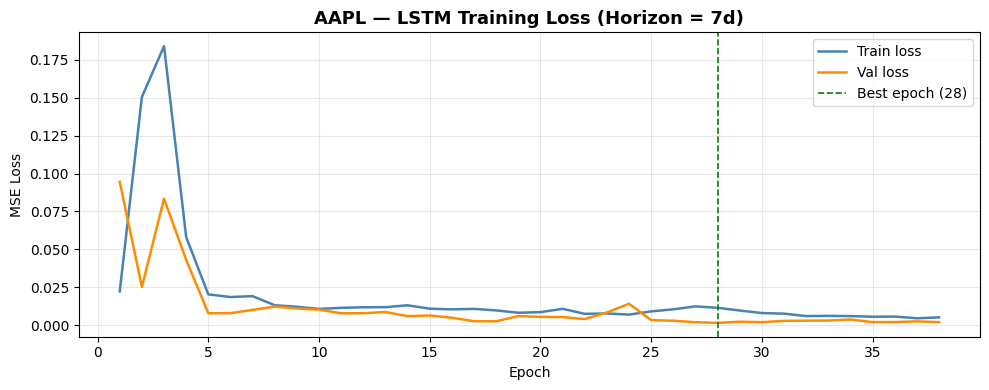

✅ Loss curve plotted | Best epoch: 28 | Best val loss: 0.001549


In [27]:
# Block 15 — Plot training loss curve

fig, ax = plt.subplots(figsize=(10, 4))

epochs_range = range(1, len(train_losses) + 1)
ax.plot(epochs_range, train_losses, color="steelblue",  label="Train loss", linewidth=1.8)
ax.plot(epochs_range, val_losses,   color="darkorange", label="Val loss",   linewidth=1.8)
ax.axvline(x=best_epoch, color="green", linestyle="--", linewidth=1.2, label=f"Best epoch ({best_epoch})")

ax.set_title(f"{TICKER} — LSTM Training Loss (Horizon = {HORIZON}d)", fontsize=13, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"✅ Loss curve plotted | Best epoch: {best_epoch} | Best val loss: {best_val_loss:.6f}")

In [28]:
# Block 16 — Load best checkpoint + run inference on test set

# Load best weights
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()
print(f"✅ Loaded best checkpoint from epoch {best_epoch}")

all_preds  = []   # scaled predictions
all_actuals = []  # scaled actuals

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        pred = model(xb)                    # (batch, horizon)
        all_preds.append(pred.cpu().numpy())
        all_actuals.append(yb.numpy())

all_preds   = np.concatenate(all_preds,   axis=0)  # (n_test_samples, horizon)
all_actuals = np.concatenate(all_actuals, axis=0)  # (n_test_samples, horizon)

print(f"   Inference complete | Predictions shape: {all_preds.shape} | Actuals shape: {all_actuals.shape}")

✅ Loaded best checkpoint from epoch 28
   Inference complete | Predictions shape: (191, 7) | Actuals shape: (191, 7)


In [29]:
# Block 17 — Inverse-scale predictions + actual prices
# The scaler expects shape (n, n_all_cols). We reconstruct dummy arrays,
# fill the Close column, inverse-transform, then extract just that column.

n_all_cols = len(ALL_COLS)

def inverse_scale_close(scaled_close_vals: np.ndarray) -> np.ndarray:
    """
    scaled_close_vals: (n_samples, horizon)
    returns:           (n_samples, horizon) in original price units
    """
    n, h = scaled_close_vals.shape
    result = np.zeros((n * h, n_all_cols))
    result[:, CLOSE_IDX] = scaled_close_vals.reshape(-1)
    inv = scaler.inverse_transform(result)
    return inv[:, CLOSE_IDX].reshape(n, h)


preds_price   = inverse_scale_close(all_preds)    # (n_test, horizon)
actuals_price = inverse_scale_close(all_actuals)  # (n_test, horizon)

# For plotting we use day-1 of horizon only (first forecast step)
pred_day1   = preds_price[:, 0]
actual_day1 = actuals_price[:, 0]

print(f"✅ Inverse-scaling complete")
print(f"   Price range — Actual: [{actual_day1.min():.2f}, {actual_day1.max():.2f}]")
print(f"   Price range — Pred:   [{pred_day1.min():.2f}, {pred_day1.max():.2f}]")

✅ Inverse-scaling complete
   Price range — Actual: [163.36, 251.87]
   Price range — Pred:   [164.01, 203.48]


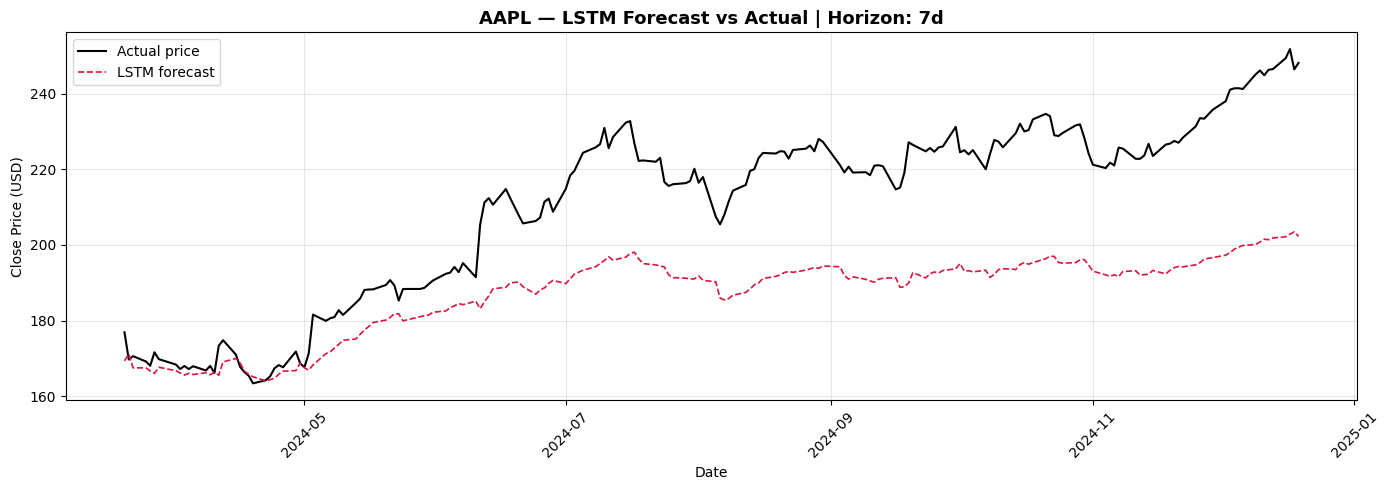

✅ Forecast vs actual plot complete


In [30]:
# Block 18 — Plot forecast vs actual (test set, day-1 of horizon)

# Align dates: each sample's prediction corresponds to WINDOW days into df_test
test_dates = df_test.index[WINDOW : WINDOW + len(pred_day1)]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates, actual_day1, color="black",   linewidth=1.5, label="Actual price")
ax.plot(test_dates, pred_day1,   color="crimson", linewidth=1.2, linestyle="--", label="LSTM forecast")

ax.set_title(f"{TICKER} — LSTM Forecast vs Actual | Horizon: {HORIZON}d", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price (USD)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("✅ Forecast vs actual plot complete")

In [31]:
# Block 19 — Compute metrics: MAE, RMSE, MAPE, Directional Accuracy

# Use day-1 predictions (first step of horizon) for all metrics
y_true = actual_day1
y_pred = pred_day1

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / np.abs(y_true))) * 100

# Directional Accuracy: did the model predict the right direction (up / down)?
# Compare predicted change from yesterday's actual vs actual change from yesterday
# "Yesterday" = the last actual price just before each test sample's prediction window
actual_yesterday = df_test["Close"].values[WINDOW - 1 : WINDOW - 1 + len(y_true)]
da = np.mean(
    np.sign(y_pred - actual_yesterday) == np.sign(y_true - actual_yesterday)
) * 100

metrics = pd.DataFrame({
    "Metric":      ["MAE", "RMSE", "MAPE (%)", "Directional Accuracy (%)"],
    "Value":       [round(mae, 4), round(rmse, 4), round(mape, 4), round(da, 2)],
    "Better when": ["↓ lower", "↓ lower", "↓ lower", "↑ higher"]
})

metrics_path = os.path.join(RESULTS_DIR, "lstm_metrics.csv")
metrics.to_csv(metrics_path, index=False)

print(f"✅ Test metrics (day-1 forecast, n={len(y_true)} samples):\n")
display(metrics)
print(f"\n💾 Saved → {metrics_path}")

✅ Test metrics (day-1 forecast, n=191 samples):



,Metric,Value,Better when
0,MAE,23.6576,↓ lower
1,RMSE,27.1626,↓ lower
2,MAPE (%),10.6181,↓ lower
3,Directional Accuracy (%),72.2500,↑ higher



💾 Saved → /content/drive/MyDrive/stock_forecasting/results/lstm_metrics.csv


In [34]:
# Block 20 — Walk-forward backtest
# Signal: predicted_price[t+1] > actual_price[t] → long; else → cash
# Transaction cost: 0.1% on every signal change

# Ensure actual_close is a 1D array
actual_close = df_test[TARGET_COL].values.squeeze()

# Align: predictions start at index WINDOW in df_test
n_bt = len(pred_day1)
actual_bt    = actual_close[WINDOW     : WINDOW + n_bt]       # prices at signal time
actual_next  = actual_close[WINDOW + 1 : WINDOW + n_bt + 1]  # next day prices
pred_bt      = pred_day1                                       # model's forecast

# Daily returns of buy-and-hold
bah_returns = (actual_next - actual_bt) / actual_bt

# Model signal: 1 = long, 0 = cash
signal = (pred_bt > actual_bt).astype(float)

# Model daily returns (before costs)
model_returns = signal * bah_returns

# Apply transaction cost on position changes
position_change = np.abs(np.diff(signal, prepend=0.0))
TC = 0.001
model_returns -= position_change * TC

# Equity curves (cumulative product, starting at 1.0)
model_equity = np.cumprod(1 + model_returns)
bah_equity   = np.cumprod(1 + bah_returns)

# Dates for plotting
bt_dates = df_test.index[WINDOW : WINDOW + n_bt]

print(f"✅ Backtest complete | {n_bt} trading days | TC = {TC*100:.1f}% per trade")
print(f"   Total trades (signal changes): {int(position_change.sum())}")
print(f"   Final model equity: {model_equity[-1]:.4f} | Buy-and-hold: {bah_equity[-1]:.4f}")

✅ Backtest complete | 191 trading days | TC = 0.1% per trade
   Total trades (signal changes): 8
   Final model equity: 1.0126 | Buy-and-hold: 1.4295


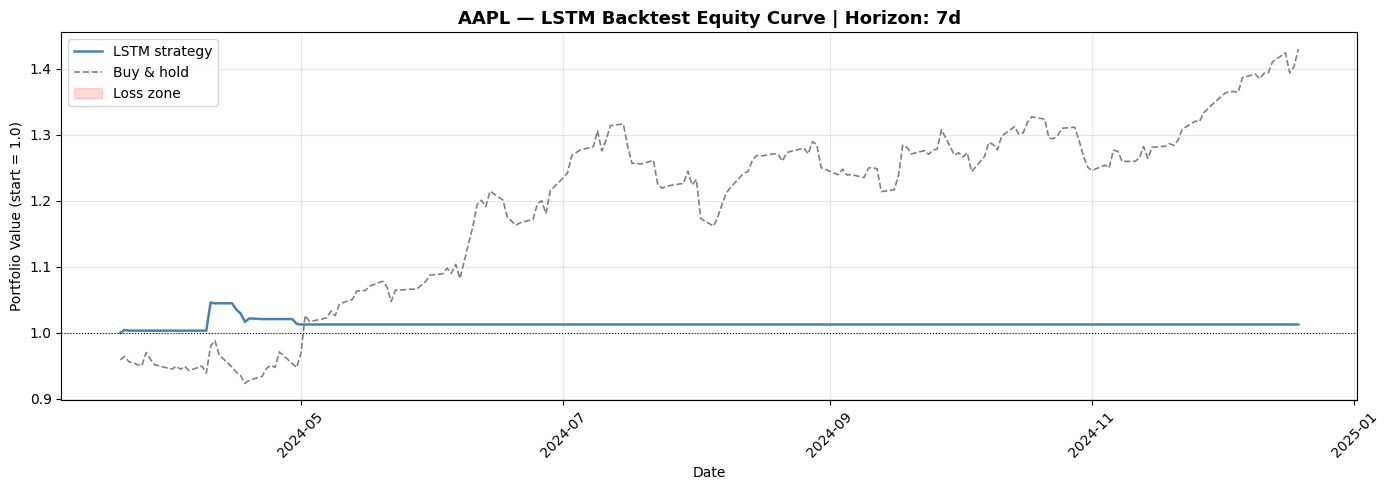

✅ Equity curve plotted


In [35]:
# Block 21 — Plot equity curve (model strategy vs buy-and-hold)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(bt_dates, model_equity, color="steelblue", linewidth=1.8, label="LSTM strategy")
ax.plot(bt_dates, bah_equity,   color="grey",      linewidth=1.2, linestyle="--", label="Buy & hold")
ax.axhline(y=1.0, color="black", linewidth=0.8, linestyle=":")

# Shade loss zone
ax.fill_between(bt_dates, model_equity, 1.0,
                where=(model_equity < 1.0), alpha=0.15, color="red", label="Loss zone")

ax.set_title(f"{TICKER} — LSTM Backtest Equity Curve | Horizon: {HORIZON}d", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value (start = 1.0)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("✅ Equity curve plotted")

In [36]:
# Block 22 — Backtest metrics: Sharpe ratio + Max Drawdown

# Sharpe ratio (annualised, risk-free rate ≈ 0 for simplicity)
mean_ret  = np.mean(model_returns)
std_ret   = np.std(model_returns) + 1e-9   # avoid division by zero
sharpe    = (mean_ret / std_ret) * np.sqrt(252)

# Maximum Drawdown
peak      = np.maximum.accumulate(model_equity)
drawdown  = (model_equity - peak) / peak
max_dd    = drawdown.min() * 100  # as percentage

# Buy-and-hold Sharpe for reference
bah_sharpe = (np.mean(bah_returns) / (np.std(bah_returns) + 1e-9)) * np.sqrt(252)
bah_peak   = np.maximum.accumulate(bah_equity)
bah_max_dd = ((bah_equity - bah_peak) / bah_peak).min() * 100

bt_metrics = pd.DataFrame({
    "Metric":         ["Sharpe Ratio", "Max Drawdown (%)"],
    "LSTM Strategy":  [round(sharpe, 4), round(max_dd, 2)],
    "Buy & Hold":     [round(bah_sharpe, 4), round(bah_max_dd, 2)]
})

print(f"✅ Backtest metrics:\n")
display(bt_metrics)

✅ Backtest metrics:



,Metric,LSTM Strategy,Buy & Hold
0,Sharpe Ratio,0.3357,2.1231
1,Max Drawdown (%),-3.1700,-11.7500


In [37]:
# Block 23 — Save model + scaler to Google Drive

MODEL_PATH  = os.path.join(MODEL_DIR, "lstm_best.pt")
SCALER_PATH = os.path.join(MODEL_DIR, "lstm_scaler.joblib")

# Model checkpoint was already saved during training (Block 14).
# Re-save here explicitly to confirm the final path.
torch.save(model.state_dict(), MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

print("✅ Artefacts saved to Google Drive:")
print(f"   Model  → {MODEL_PATH}")
print(f"   Scaler → {SCALER_PATH}")
print(f"\n📋 Reload with:")
print(f"   model.load_state_dict(torch.load('{MODEL_PATH}', map_location=DEVICE))")
print(f"   scaler = joblib.load('{SCALER_PATH}')")
print(f"\n🏁 colab_lstm.ipynb complete for {TICKER} | Horizon: {HORIZON}d")

✅ Artefacts saved to Google Drive:
   Model  → /content/drive/MyDrive/stock_forecasting/models/lstm_best.pt
   Scaler → /content/drive/MyDrive/stock_forecasting/models/lstm_scaler.joblib

📋 Reload with:
   model.load_state_dict(torch.load('/content/drive/MyDrive/stock_forecasting/models/lstm_best.pt', map_location=DEVICE))
   scaler = joblib.load('/content/drive/MyDrive/stock_forecasting/models/lstm_scaler.joblib')

🏁 colab_lstm.ipynb complete for AAPL | Horizon: 7d
